# Library


In [3]:
# 1. Standard Libraries
import os
import re
import random
from collections import Counter

# 2. Data Analysis & Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# 3. Machine Learning Metrics & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

# 4. Deep Learning (PyTorch & Vision)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.transforms import ToPILImage

# 5. Specialized Tools (Explainability/Grad-CAM)
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask

# Dataset Exploration


### Data Loading

(**The Dataset is created starting from the follwing link**: https://dataverse.harvard.edu/dataverse/imperfectfoods)

The dataset path is defined and all valid image files in the folder are listed, with the total number counted to ensure correct loading.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
DATASET_PATH = "/content/drive/MyDrive/All Fruits/All Fruits"

image_files = [
    f for f in os.listdir(DATASET_PATH)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

print(f"Total images: {len(image_files)}")


Total images: 1484


### Filename Parsing and Metadata Extraction

The image filenames are standardized, cleaned of unnecessary suffixes, and parsed to extract the fruit type and quality labels encoded in their names.

This information is then organized into a structured tabular format, enabling efficient inspection and preparation of the dataset for further analysis



In [6]:
def parse_filename(filename):
    name = filename.lower()


    name = re.sub(r"\s*\(\d+\)", "", name)
    name = os.path.splitext(name)[0]

    parts = name.split("_")

    fruit = parts[0]
    quality = parts[1]

    return fruit, quality


In [7]:
data = []

for img in image_files:
    fruit, quality = parse_filename(img)
    data.append({
        "filename": img,
        "fruit": fruit,
        "quality": quality
    })

df = pd.DataFrame(data)
df.head()


,filename,fruit,quality
0,Apple_good (532).jpg,apple,good
1,Apple_good (533).jpg,apple,good
2,Apple_good (534).jpg,apple,good
3,Apple_good (535).jpg,apple,good
4,Apple_good (536).jpg,apple,good


### Data Distribution Analysis and Visualization

In this step, the distribution of images across quality classes is analyzed by counting the number of samples per label and visualizing the results with a bar plot.

This allows to identify the distribution of labels, which is essential for selecting appropriate training strategies.


In [8]:
quality_counts = df["quality"].value_counts()
quality_counts


,count
quality,
good,764
imperfect,646
bad,74


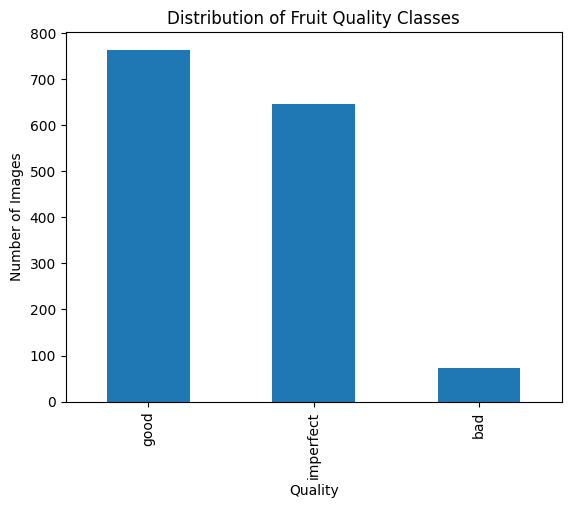

In [9]:
plt.figure()
quality_counts.plot(kind="bar")
plt.title("Distribution of Fruit Quality Classes")
plt.xlabel("Quality")
plt.ylabel("Number of Images")
plt.show()


Now the class distribution is also presented in percentage terms to provide a clearer view of the relative representation of each quality category.


In [10]:
total = len(df)

for q, count in quality_counts.items():
    perc = count / total * 100
    print(f"{q}: {count} images ({perc:.2f}%)")


good: 764 images (51.48%)
imperfect: 646 images (43.53%)
bad: 74 images (4.99%)


The output shows a clear class imbalance, with the 'bad' quality class being significantly underrepresented compared to the 'good' and 'imperfect' classes.

This will be addressed using data augmentation and class weighting.

The distribution of images across fruit types is analyzed and visualized to identify any over/under representation, providing insights into dataset composition.


In [11]:
fruit_counts = df["fruit"].value_counts()
fruit_counts


,count
fruit,
apple,897
strawberry,378
papaya,25
cherry,23
peach,22
banana,20
kiwi,17
plum,17
grapefruit,16


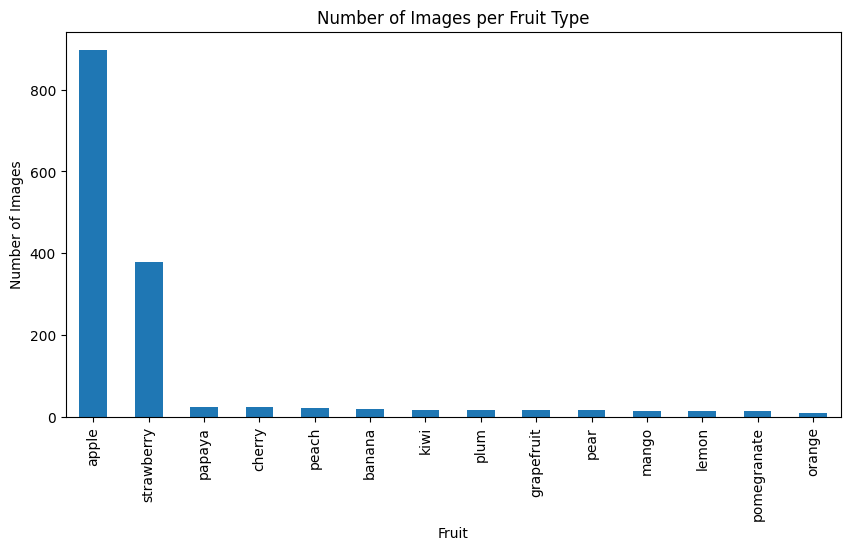

In [12]:
plt.figure(figsize=(10,5))
fruit_counts.plot(kind="bar")
plt.title("Number of Images per Fruit Type")
plt.xlabel("Fruit")
plt.ylabel("Number of Images")
plt.show()


The output reveals a strong imbalance among fruit types, with apple and strawberry dominating the dataset while many other fruits have very few samples.

### Visual Sample Inspection Function

Finally, example images from each quality class are displayed by randomly selecting and plotting samples, providing a visual check to verify that the classes are distinguishable and correctly labeled.



In [13]:
def show_examples(df, quality, n=4):
    samples = df[df["quality"] == quality].sample(n)

    plt.figure(figsize=(10,3))
    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(DATASET_PATH, row["filename"])
        img = Image.open(img_path)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(quality)
    plt.show()


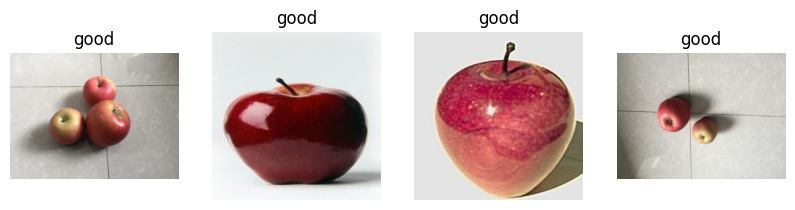

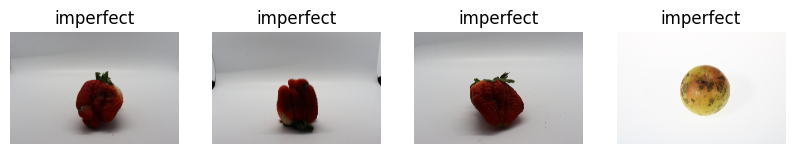

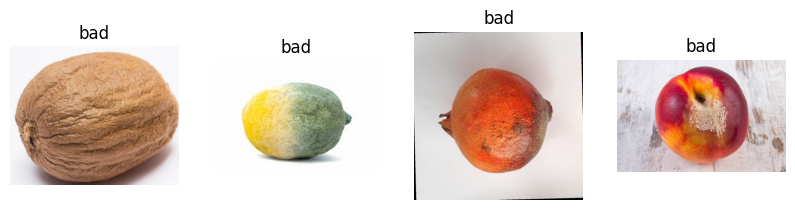

In [14]:
show_examples(df, "good")
show_examples(df, "imperfect")
show_examples(df, "bad")


Visual inspection of the images highlights clear visual differences among quality classes.
Good fruits appear uniform in color and shape, while imperfect fruits show minor defects such as small spots or irregularities.
Bad fruits often present visible spoilage, bruises, or discoloration, confirming that visual cues are informative for classification.

# Data Preprocessing

### Image Integrity Validation and Corruption Check

All images in the dataset are checked for corruption to ensure they can be opened correctly, preventing errors during preprocessing and model training.

A target image size of 224 is set to match typical CNN input requirements, and a validation function attempts to open each image, separating valid images from corrupted ones.

This process identifies unusable files and ensures that only clean, readable images are included, maintaining data quality and reliability for training.

In [15]:
IMG_SIZE = 224

def is_image_valid(path):
    try:
        img = Image.open(path)
        img.verify()
        return True
    except:
        return False


In [16]:
valid_images = []
corrupted_images = []

for img_name in os.listdir(DATASET_PATH):
    img_path = os.path.join(DATASET_PATH, img_name)

    if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        if is_image_valid(img_path):
            valid_images.append(img_name)
        else:
            corrupted_images.append(img_name)

print(f"Valid images: {len(valid_images)}")
print(f"Corrupted images: {len(corrupted_images)}")


Valid images: 1484
Corrupted images: 0


All images are valid, indicating a clean dataset with no corrupted files.

Images were normalized using ImageNet mean and standard deviation to ensure compatibility with pre-trained convolutional neural networks and improve training stability.

In [17]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


### Image Augmentation and Training Pipeline

In this step, a preprocessing and augmentation pipeline is applied to the training images to prepare them for a convolutional neural network.

All images are first converted to RGB format to ensure three color channels, which is required by most CNN architectures.

The pipeline then introduces variability by randomly cropping and resizing regions of the image, flipping them horizontally with a certain probability, applying small rotations, and slightly altering brightness, contrast, saturation, and hue.
These transformations help the model become less sensitive to changes in position, orientation, or lighting conditions.

After these augmentations, the images are converted into tensors and standardized using ImageNet statistics, ensuring compatibility with pre-trained networks and improving training stability.

In [18]:
train_transforms = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),

    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


| Tecnica      | Motivo                 |
| ------------ | ---------------------- |
| Flip         | Symmetric fruits       |
| Rotation     | Variable orientation   |
| Color jitter | Light and maturation   |
| Random crop  | Variable position      |


These transformations do not create new images on disk but generate randomized versions of each image on the fly during training. This approach increases the effective diversity of the dataset, helping the model generalize better without requiring additional storage.

### Validation and Testing Transformation Pipeline

In this step, a transformation pipeline is created for validation and test images to ensure consistent and reliable evaluation.

All images are converted to RGB to have three color channels and resized to a fixed target size, providing a uniform input shape for the model.

Pixel values are then standardized using ImageNet statistics, guaranteeing that the images are processed consistently without any type of data augmentation, unlike training images, so that model performance can be assessed fairly.


In [19]:
val_test_transforms = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


### Visualization of Data Augmentation Effects

In this final step of preprocessing phase, training transformations are applied to a sample image multiple times to visualize how augmentation alters it while keeping it realistic.

A random image is selected and repeatedly transformed, with the resulting variations displayed side by side.


In [20]:
def show_augmented_examples(image_path, transform, n=5):
    img = Image.open(image_path)

    plt.figure(figsize=(15,3))
    for i in range(n):
        augmented = transform(img)
        augmented = augmented.permute(1, 2, 0)
        augmented = augmented * torch.tensor(IMAGENET_STD) + torch.tensor(IMAGENET_MEAN)
        augmented = augmented.clamp(0, 1)

        plt.subplot(1, n, i+1)
        plt.imshow(augmented)
        plt.axis("off")
    plt.show()


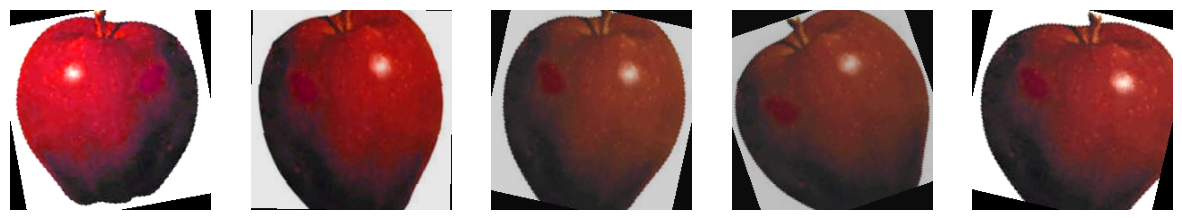

In [21]:
sample_image = os.path.join(DATASET_PATH, valid_images[random.randint(0, len(valid_images)-1)])
show_augmented_examples(sample_image, train_transforms)

The output shows multiple variations of the same image, allowing verification that the augmentation increases data diversity without compromising image quality.

# Dataset & DataLoader

### Numerical Label Encoding and Mapping

In this step, each quality class is assigned a numeric label for model training: “good” is mapped to 0, “imperfect” is mapped to 1, and “bad” is mapped to 2.

This numeric encoding allows the model to interpret the labels during training.


In [23]:
label_map = {
    "good": 0,
    "imperfect": 1,
    "bad": 2
}

df["label"] = df["quality"].map(label_map)
df.head()


,filename,fruit,quality,label
0,Apple_good (532).jpg,apple,good,0
1,Apple_good (533).jpg,apple,good,0
2,Apple_good (534).jpg,apple,good,0
3,Apple_good (535).jpg,apple,good,0
4,Apple_good (536).jpg,apple,good,0


### Stratified Dataset Splitting

The dataset is divided into training, validation, and test sets to ensure proper model development and evaluation. The training set, comprising 70% of the data, is used to fit the model, while the remaining 30% is reserved for creating validation and test sets. This temporary set is evenly split so that both validation and test sets represent 15% of the total data.

Stratified splitting is applied in order to address the class imbalance observed during the exploratory phase. Thus, it is ensuring that each subset maintains the same proportion of each class. This preserves balanced representation across all sets and allows for a more reliable assessment of model performance.

In [24]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)


In [25]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)


In [26]:
def print_split_distribution(df, name):
    print(f"\n{name}")
    print(df["quality"].value_counts(normalize=True))

print_split_distribution(train_df, "TRAIN")
print_split_distribution(val_df, "VALIDATION")
print_split_distribution(test_df, "TEST")



TRAIN
quality
good         0.514451
imperfect    0.435453
bad          0.050096
Name: proportion, dtype: float64

VALIDATION
quality
good         0.515695
imperfect    0.434978
bad          0.049327
Name: proportion, dtype: float64

TEST
quality
good         0.515695
imperfect    0.434978
bad          0.049327
Name: proportion, dtype: float64


### Custom PyTorch Dataset Implementation

This step defines a custom dataset for our images, providing a structured way to load the images and their corresponding labels for model training and evaluation.

The dataset receives a table containing filenames and labels, along with the folder path where the images are stored and optional image transformations.

It allows accessing the total number of images and retrieving individual items by reading the filename, loading the image in RGB format, obtaining the associated label, and applying any transformations.

Each retrieval returns the processed image together with its label, enabling efficient batching and streamlined use in training and evaluation.

In [27]:
class ImperfectFoodsDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, "filename"]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")
        label = self.df.loc[idx, "label"]

        if self.transform:
            image = self.transform(image)

        return image, label


### Dataset Instance Creation

Building on the custom dataset structure, three dataset objects are created for training, validation, and testing using the splits previously defined.

Each dataset applies its respective transformation pipeline: the training set uses the augmentation pipeline to increase variability and improve generalization, while the validation and test sets use the consistent preprocessing pipeline to ensure reliable and fair evaluation.

This setup combines the stratified splitting strategy and the preprocessing approaches discussed earlier to prepare the data effectively.

In [28]:
train_dataset = ImperfectFoodsDataset(
    train_df,
    DATASET_PATH,
    transform=train_transforms
)

val_dataset = ImperfectFoodsDataset(
    val_df,
    DATASET_PATH,
    transform=val_test_transforms
)

test_dataset = ImperfectFoodsDataset(
    test_df,
    DATASET_PATH,
    transform=val_test_transforms
)


### DataLoader Configuration and Batching

Eeach PyTorch dataset is now wrapped into a DataLoader to handle batching, ordering, and efficient loading.

The training DataLoader processes 32 images at a time and randomizes their order each epoch to improve generalization, while the validation and test DataLoaders process the same batch size but maintain a fixed order to ensure stable and consistent evaluation.

This setup leverages the earlier dataset splits and preprocessing strategies, enabling efficient training and reliable assessment of model performance.

In [29]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


### Batch Verification and Dimensionality Check

Finally, a sample batch is extracted from the training DataLoader to verify that images and labels are correctly loaded and formatted.

In [30]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels)


torch.Size([32, 3, 224, 224])
tensor([0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 1, 1, 0, 1, 0, 0, 0])


The batch contains 32 images with three color channels and a size of 224x224, matching the expected input shape for the model, and the corresponding labels show the correct class assignments for each image, confirming that the data loading, transformations, and batching are working properly.


In Summary in this step, the dataset was prepared for model training by organizing the images and labels into a structured pipeline.
First, the dataset was split into training (70%), validation (15%), and test (15%) subsets using stratified sampling to preserve the original class distribution of fruit quality (good, imperfect, bad) across all splits. This ensures a fair and reliable evaluation of the model.

A custom PyTorch Dataset class was implemented to handle image loading, preprocessing, and label assignment. Each image is loaded from disk, converted to RGB format, and transformed using the preprocessing and data augmentation techniques defined in the previous step. The corresponding quality label is returned together with the image tensor.

Finally, PyTorch DataLoaders were used to efficiently feed data to the neural network in mini-batches. Shuffling was applied only to the training set to improve generalization, while validation and test sets were kept fixed. This modular design allows a clean separation between data handling and model training, making the pipeline scalable and reproducible.

# Baseline Model

### Hardware Selection and Model Initialization

The code first checks the available hardware and uses the GPU if CUDA is supported, since it allows much faster training. If a GPU is not available, the CPU is used instead.

It then loads ResNet-18, a popular and efficient convolutional neural network. The model is initialized with pre-trained weights from the ImageNet dataset, so it already knows how to recognize basic visual features like edges and shapes.

Thanks to its lightweight structure with only 18 layers, ResNet-18 offers a good balance between accuracy, training speed, and memory usage, making it well suited for image classification tasks.

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


### Feature Extraction Setup (Freezing Layers)

The script freezes all the pre-trained weights of the ResNet-18 model by setting requires_grad = False. This means the internal layers of the network are not updated during training.

By disabling gradient computation for these layers, training becomes more efficient, with lower computational cost and memory usage. In this setup, ResNet-18 is used as a fixed feature extractor, keeping the visual knowledge learned from ImageNet.

Only the final classification layer is trained on the fruit quality dataset. This helps avoid damaging the pre-trained features, leading to more stable training and faster convergence.

In [32]:
for param in model.parameters():
    param.requires_grad = False


### Classifier Modification and Device Transfer

The code accesses model.fc, which is the final fully connected layer of ResNet-18. In the original ImageNet model, this layer outputs 1,000 classes.

It then reads model.fc.in_features to get the size of the feature vector produced by the network (512 for ResNet-18). Using this value, the original layer is replaced with a new linear layer that outputs 3 classes: good, imperfect, and bad.

This new layer is trainable by default, so during training only this final classification head is updated. Finally, model.to(device) moves the entire model to the selected device, ensuring that all computations run on the same hardware.

In [33]:
model.fc


Linear(in_features=512, out_features=1000, bias=True)

In [34]:
num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 3)

model = model.to(device)


### Loss Function and Optimizer Configuration

The training uses nn.CrossEntropyLoss() as the loss function, which is the standard choice for multi-class classification. It measures how different the model’s predictions are from the true class labels.

The Adam optimizer is used because it adapts the learning rate for each parameter, usually leading to faster and more stable training than basic gradient descent.

Only the parameters of the final fully connected layer are passed to the optimizer, so only this classification head is updated while the pre-trained backbone remains unchanged. The learning rate is set to 1e-3, which provides a good balance between learning speed and training stability.

In [35]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)


## Training loop (baseline)

### Training Step Logic (One Epoch)

The training loop starts by setting the model to training mode with model.train(), which is important for layers like Dropout and Batch Normalization to work correctly.

Before processing each batch, optimizer.zero_grad() clears old gradients so they do not accumulate. The model then performs a forward pass to produce predictions, the loss is computed using the criterion, and loss.backward() calculates the gradients. Finally, optimizer.step() updates the weights of the classifier head.

During training, the code tracks the total loss and the number of correct predictions. The predicted class is obtained by selecting the output with the highest probability. At the end of the loop, the average loss and overall accuracy are returned.

In [36]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    return running_loss / len(loader), acc


### Model Evaluation and Metrics Collection

The evaluation phase starts by setting the model to evaluation mode with model.eval(). This ensures consistent behavior by disabling Dropout and using fixed statistics for Batch Normalization.

Gradient computation is turned off using torch.no_grad(), which reduces memory usage and speeds up inference. During evaluation, the model’s predictions and the true labels are collected, moved to the CPU, and converted to NumPy arrays for later analysis.

The code tracks the total validation loss and computes the accuracy over all samples. Finally, it returns the average loss, the accuracy, and the full lists of predictions and labels for more detailed performance evaluation.

In [37]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return running_loss / len(loader), acc, all_labels, all_preds


### Main Training Loop Execution

The training is run for 5 epochs, meaning the model sees the entire training dataset five times. Since only the final layer is trained in transfer learning, a small number of epochs is usually enough.

In each epoch, the model is trained using train_one_epoch, which updates the weights and returns the training loss and accuracy. The model is then evaluated on the validation set to check how well it generalizes and to detect possible overfitting.

After each epoch, the training and validation metrics are printed. Showing accuracies with three decimal places makes it easier to track small but consistent improvements over time.

In [38]:
EPOCHS = 5

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, criterion, device
    )

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")


Epoch 1/5
Train Acc: 0.776 | Val Acc: 0.803
Epoch 2/5
Train Acc: 0.881 | Val Acc: 0.861
Epoch 3/5
Train Acc: 0.894 | Val Acc: 0.901
Epoch 4/5
Train Acc: 0.896 | Val Acc: 0.901
Epoch 5/5
Train Acc: 0.905 | Val Acc: 0.906


### Model Performance Evaluation

The model is evaluated one last time on the validation set to collect the true labels and the predicted classes. This data allows a deeper analysis of how the model behaves.

Using Scikit-Learn’s classification_report, performance is measured in more detail than simple accuracy. For each class—good, imperfect, and bad—the report shows precision, recall, and F1-score, giving insight into both correctness and coverage.

By labeling each class explicitly, the report makes it easy to see if the model struggles with specific categories, such as confusing imperfect and bad fruits. It also includes macro and weighted averages, which provide an overall view of performance while accounting for class imbalance.

In [39]:
_, _, y_true, y_pred = evaluate(
    model, val_loader, criterion, device
)

print(classification_report(
    y_true,
    y_pred,
    target_names=["good", "imperfect", "bad"]
))

              precision    recall  f1-score   support

        good       0.90      0.98      0.94       115
   imperfect       0.94      0.91      0.92        97
         bad       0.33      0.09      0.14        11

    accuracy                           0.91       223
   macro avg       0.72      0.66      0.67       223
weighted avg       0.89      0.91      0.89       223



### Confusion Matrix Visualization and Analysis

The confusion_matrix shows how many samples of each actual class were predicted in each category. Rows represent true classes, and columns represent predicted classes.

The matrix is visualized as a heatmap using plt.imshow(). Brighter squares along the diagonal show more correct predictions. Numbers and percentages are added with plt.text() to highlight which classes are being confused, such as "Imperfect" fruits being misclassified as "Bad."

A normalized version shows percentages per class, which is helpful for imbalanced datasets, as it effectively displays the recall for each class. These visualizations are essential for spotting model biases that overall accuracy might hide.

In [40]:
cm = confusion_matrix(y_true, y_pred)
cm


array([[113,   2,   0],
       [  7,  88,   2],
       [  6,   4,   1]])

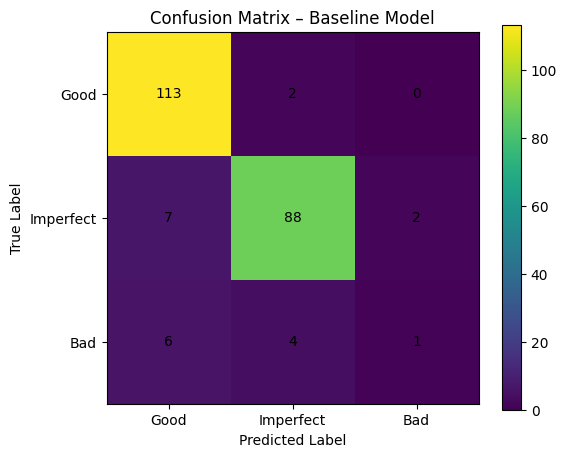

In [41]:
class_names = ["Good", "Imperfect", "Bad"]

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.colorbar()

plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Baseline Model")

# Annotazioni numeriche
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


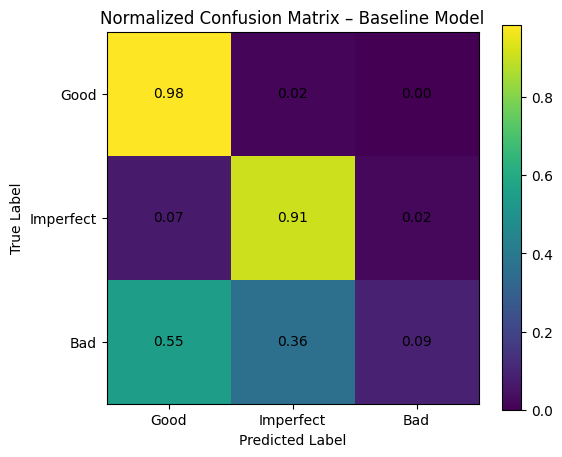

In [42]:
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm)
plt.colorbar()

plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix – Baseline Model")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}",
                 ha="center", va="center")

plt.show()


The confusion matrix shows that the baseline model performs well in distinguishing good and imperfect fruits, with most errors occurring between these adjacent quality classes. This behavior is expected due to the subtle visual differences between minor defects and high-quality fruits.

However, the model struggles significantly with the bad class, which is frequently misclassified as good or imperfect. This is mainly due to the limited number of bad samples in the dataset and the use of a frozen baseline model. These results highlight the need for class-aware strategies and fine-tuning to improve the detection of severely defective fruits.

# Advanced Model

### Hardware Selection and EfficientNet Initialization

The code first checks if a compatible NVIDIA GPU is available using torch.cuda.is_available(). If so, it uses the GPU for faster computation; otherwise, it defaults to the CPU.

It then loads EfficientNet-B0, a modern architecture that balances accuracy and efficiency using compound scaling of depth, width, and resolution. With pretrained=True, the model starts with ImageNet weights, giving it prior knowledge of visual features like textures, shapes, and fruit patterns.

EfficientNet-B0 is also lightweight and fast, often achieving higher accuracy than ResNet with fewer parameters, making it ideal for mobile or resource-limited applications.

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(pretrained=True)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 140MB/s]


### EfficientNet Classifier Modification

In EfficientNet, the classification layers are stored in model.classifier rather than .fc like in ResNet. The code accesses model.classifier[1], the final linear layer, and checks its input size (1280 for EfficientNet-B0) to match the new layer.

The original layer is replaced with a new nn.Linear layer that outputs 3 classes: good, imperfect, and bad. This new layer is trainable by default (requires_grad=True).

Finally, model.to(device) moves the full model to the GPU if available, ensuring it works with the data batches from train_loader.


In [44]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [45]:
num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(num_features, 3)

model = model.to(device)


### Feature Extraction Strategy (Backbone Freezing)

In EfficientNet, the convolutional backbone is in model.features. The code freezes these layers by setting requires_grad = False, so they are not updated during training.

This preserves the ImageNet-learned feature detectors for shapes and textures, while only the new classifier head is trained. Freezing the backbone also reduces the number of trainable parameters, making training faster and using less GPU memory.

In [46]:
for param in model.features.parameters():
    param.requires_grad = False


## Weighted Loss

### Class Weight Calculation for Imbalance Handling

The code first counts how many samples exist for each class (good, imperfect, bad). Since some classes are less frequent, the model could ignore them if not adjusted.

To fix this, it computes the inverse of these counts, giving higher weight to rare classes and lower weight to common ones. The weights are then normalized so they sum to 1, keeping the loss scale stable.

Finally, the weights are converted to a tensor on the correct device and passed to the loss function, making the model pay more attention to underrepresented classes.

In [47]:
class_counts = train_df["label"].value_counts().sort_index()
class_counts


,count
label,
0,534
1,452
2,52


In [48]:
weights = 1.0 / class_counts
weights = weights / weights.sum()

class_weights = torch.tensor(weights.values, dtype=torch.float).to(device)
class_weights


tensor([0.0803, 0.0949, 0.8248], device='cuda:0')

### Weighted Loss Function Implementation

By passing weight=class_weights to nn.CrossEntropyLoss(), the model uses a weighted loss to handle class imbalance.

Now, mistakes on rare classes like "Imperfect" or "Bad" are penalized more than errors on the majority "Good" class. This forces the model to learn features that distinguish the less frequent classes, rather than taking the easy route of always predicting the most common class.

During backpropagation, the gradients for minority classes are larger, so the optimizer adjusts the weights more to improve their predictions.

In [49]:
criterion = nn.CrossEntropyLoss(weight=class_weights)


### Advanced Optimization and Learning Rate Scheduling

The optimizer is now AdamW, which is widely used for fine-tuning. Unlike standard Adam, AdamW applies weight decay directly to the weights, helping prevent overfitting. A small weight decay of 1e-4 keeps the classifier weights from growing too large.

A learning rate scheduler, ReduceLROnPlateau, monitors the validation loss and reduces the learning rate by half if it stops improving for 2 epochs. This lets the model take smaller steps to reach a better minimum without reacting to minor fluctuations. Since the goal is to minimize loss, the scheduler is set in "min" mode.

In [50]:
optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


In [51]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)


### Final Training Execution (EfficientNet + Scheduler)

Training is now run for 10 epochs, giving EfficientNet more time to fine-tune the connection between features and labels.

The scheduler scheduler.step(val_loss) monitors the validation loss and lowers the learning rate if improvement stalls, helping the model reach a better minimum without overshooting.

With class_weights applied, the model also pays more attention to the underrepresented "Bad" and "Imperfect" fruits.

During training, Train Acc shows performance on the training set, while Val Acc measures how well the model generalizes to new, unseen images.


In [52]:
EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")


Epoch 1/10
Train Acc: 0.671 | Val Acc: 0.879
Epoch 2/10
Train Acc: 0.873 | Val Acc: 0.892
Epoch 3/10
Train Acc: 0.890 | Val Acc: 0.910
Epoch 4/10
Train Acc: 0.884 | Val Acc: 0.910
Epoch 5/10
Train Acc: 0.899 | Val Acc: 0.906
Epoch 6/10
Train Acc: 0.900 | Val Acc: 0.897
Epoch 7/10
Train Acc: 0.903 | Val Acc: 0.910
Epoch 8/10
Train Acc: 0.908 | Val Acc: 0.910
Epoch 9/10
Train Acc: 0.901 | Val Acc: 0.906
Epoch 10/10
Train Acc: 0.901 | Val Acc: 0.906


### Partial Unfreezing (Fine-Tuning the Backbone)

Instead of training just the classifier, the last two blocks of EfficientNet’s backbone (model.features[-2:]) are unfrozen.

Early layers still detect basic features like edges and colors, while the unfrozen layers learn complex patterns specific to fruit quality, such as bruises or discoloration.

This approach lets the model specialize without risking catastrophic forgetting or overfitting, since most of the backbone remains frozen.

In [53]:
for param in model.features[-2:].parameters():
    param.requires_grad = True


### Selective Optimizer Configuration

The optimizer uses filter(lambda p: p.requires_grad, ...) to update only the unfrozen layers—the last two backbone blocks and the classifier head.

The learning rate is lowered to 1e-4 to fine-tune gently, preserving the pre-trained ImageNet features. Weight decay (1e-4) continues to regularize the model and prevent overfitting.

Filtering out frozen parameters also saves memory, since the optimizer doesn’t track unused layers.

In [54]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)


### Fine-Tuning Execution Phase

Fine-tuning runs for just 5 epochs (EPOCHS_FINE = 5) since the model is already well-trained. A few passes are enough to adjust the last layers without over-altering the backbone.

During this phase, the final feature detectors are refined to better capture the visual cues of the fruit dataset. Training accuracy usually approaches 100%, while validation accuracy should peak, squeezing out the last few points of performance.

The scheduler remains active, reducing the learning rate if progress stalls, keeping training stable.

In [55]:
EPOCHS_FINE = 5

for epoch in range(EPOCHS_FINE):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    print(f"[Fine-tuning] Epoch {epoch+1}/{EPOCHS_FINE}")
    print(f"Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")


[Fine-tuning] Epoch 1/5
Train Acc: 0.913 | Val Acc: 0.919
[Fine-tuning] Epoch 2/5
Train Acc: 0.919 | Val Acc: 0.897
[Fine-tuning] Epoch 3/5
Train Acc: 0.929 | Val Acc: 0.910
[Fine-tuning] Epoch 4/5
Train Acc: 0.932 | Val Acc: 0.906
[Fine-tuning] Epoch 5/5
Train Acc: 0.940 | Val Acc: 0.928


### Final Evaluation of Fine-Tuned EfficientNet

The model is evaluated one last time on the validation set, storing results in y_true_adv and y_pred_adv to compare with the baseline.

The classification report shows the effect of your improvements: class weights boost recall for "bad" and "imperfect" fruits, while fine-tuning the backbone raises the F1-score for these harder-to-classify categories.

Macro and weighted averages should now be closer, reflecting more balanced performance. Any remaining low precision for "imperfect" fruit highlights where the model still struggles with subtle defects.


In [56]:

_, _, y_true_adv, y_pred_adv = evaluate(
    model, val_loader, criterion, device
)

print(classification_report(
    y_true_adv,
    y_pred_adv,
    target_names=["good", "imperfect", "bad"]
))


              precision    recall  f1-score   support

        good       0.94      0.96      0.95       115
   imperfect       1.00      0.90      0.95        97
         bad       0.53      0.91      0.67        11

    accuracy                           0.93       223
   macro avg       0.82      0.92      0.85       223
weighted avg       0.95      0.93      0.93       223



In Summary: An advanced model based on EfficientNet-B0 was implemented using transfer learning. The convolutional backbone was initially frozen and only the classification head was trained. Subsequently, a fine-tuning phase was applied by unfreezing the last convolutional blocks. To address class imbalance, a weighted cross-entropy loss was adopted. This strategy significantly improves the recognition of severely defective fruits compared to the baseline model.

### Visualizing Advanced Model Performance

The new confusion matrix (cm_adv) shows how EfficientNet with fine-tuning improves predictions. A clearer diagonal means more correct classifications.

The heatmap uses blue for intensity and red text for readability. The normalized version is key—it shows the percentage of correct predictions per class. For example, a 0.95 on the "Bad" row means 95% of rotten fruit are correctly identified.

Off-diagonal cells reveal remaining misclassifications, such as "Imperfect" being confused with "Good." This also shows whether class_weights worked: even with fewer "Bad" samples, the model should perform well on minority classes.

In [57]:
cm_adv = confusion_matrix(y_true_adv, y_pred_adv)
cm_adv


array([[110,   0,   5],
       [  6,  87,   4],
       [  1,   0,  10]])

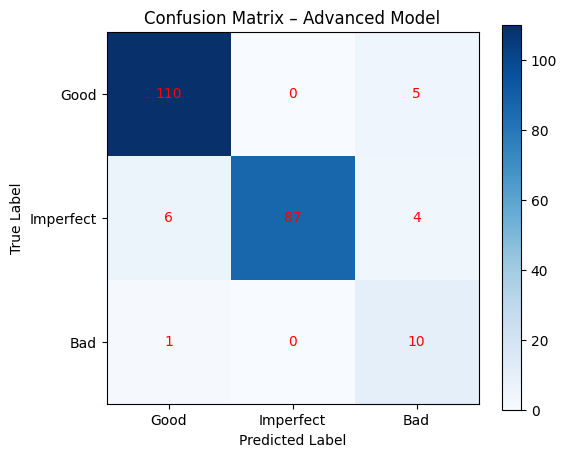

In [58]:
class_names = ["Good", "Imperfect", "Bad"]

plt.figure(figsize=(6, 5))
plt.imshow(cm_adv, cmap='Blues')
plt.colorbar()

plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Advanced Model")


for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm_adv[i, j], ha="center", va="center", color='red')

plt.show()


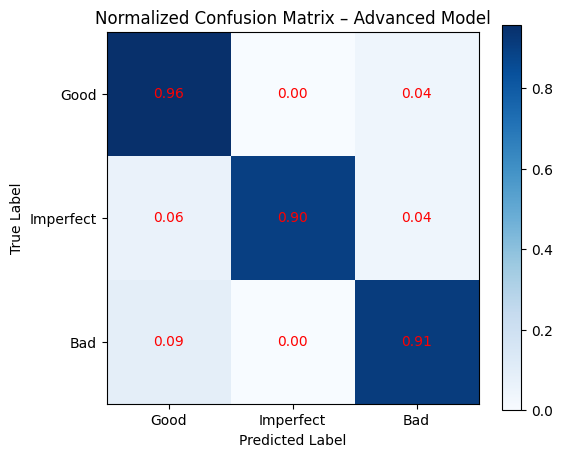

In [59]:
cm_adv_norm = cm_adv.astype("float") / cm_adv.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_adv_norm, cmap='Blues')
plt.colorbar()

plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix – Advanced Model")


for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, f"{cm_adv_norm[i, j]:.2f}", ha="center", va="center", color='red')

plt.show()


# Model Evaluation on Test Set


### Final Test Set Evaluation

Running the model on the test_loader gives the final measure of performance on completely unseen images, showing how it will work in the real world.

The classification report reveals whether high validation performance holds, with F1-score summarizing how well all three fruit classes are identified.

The normalized confusion matrix shows recall per class. For example, if "Imperfect" is predicted as "Good" 15–20% of the time, you can pinpoint the model’s weak spots.

If test metrics are close to validation results (within 1–2%), the model is stable and ready for deployment. Large drops indicate overfitting.

In [60]:

_, _, y_true_adv_test, y_pred_adv_test = evaluate(
    model, test_loader, criterion, device
)

print(classification_report(
    y_true_adv_test,
    y_pred_adv_test,
    target_names=["good", "imperfect", "bad"]
))


              precision    recall  f1-score   support

        good       0.95      0.92      0.94       115
   imperfect       0.95      0.92      0.93        97
         bad       0.44      0.73      0.55        11

    accuracy                           0.91       223
   macro avg       0.78      0.86      0.81       223
weighted avg       0.93      0.91      0.92       223



In [61]:
cm_adv_test = confusion_matrix(y_true_adv_test, y_pred_adv_test)
cm_adv_test

array([[106,   3,   6],
       [  4,  89,   4],
       [  1,   2,   8]])

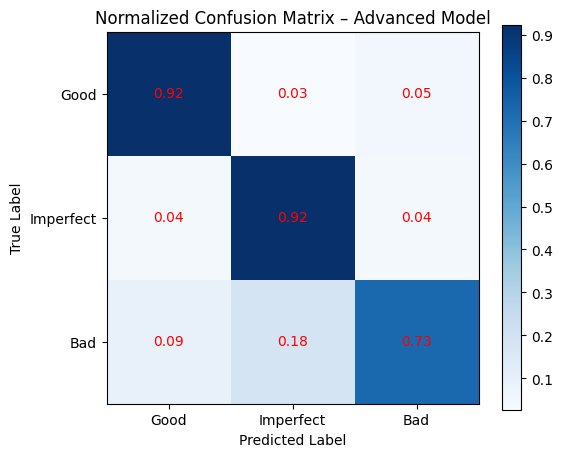

In [62]:
cm_adv_norm_test = cm_adv_test.astype("float") / cm_adv_test.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_adv_norm_test, cmap='Blues')
plt.colorbar()

plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix – Advanced Model")


for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, f"{cm_adv_norm_test[i, j]:.2f}", ha="center", va="center", color='red')

plt.show()


### Quantitative Error Breakdown on Test Set

By filtering y_true_adv_test, errors are broken down into specific failure types for each class (0: Good, 1: Imperfect, 2: Bad).

False Positives (FP):

Class 0 (Good) – high FP means the model is "too optimistic," labeling damaged fruit as good.

Class 2 (Bad) – high FP means the model is "too strict," discarding perfectly good fruit.

False Negatives (FN):

Class 2 (Bad) – high FN is most dangerous, letting rotten fruit pass.

This breakdown helps set confidence thresholds: it’s often better to accept a few FP for "Bad" fruit than any FN, prioritizing safety and quality.


In [63]:

test_results = pd.DataFrame({
    "true": y_true_adv_test,
    "pred": y_pred_adv_test
})


for cls in range(3):
    fp = test_results[(test_results["pred"] == cls) & (test_results["true"] != cls)]
    print(f"Class {cls} false positives: {len(fp)}")


for cls in range(3):
    fn = test_results[(test_results["pred"] != cls) & (test_results["true"] == cls)]
    print(f"Class {cls} false negatives: {len(fn)}")


Class 0 false positives: 5
Class 1 false positives: 5
Class 2 false positives: 10
Class 0 false negatives: 9
Class 1 false negatives: 8
Class 2 false negatives: 3


### Visual Error Inspection

This code moves from numbers to images, letting you see the exact mistakes the model makes.

Common edge cases include:

Lighting issues – very dark or bright images cause errors.

Ambiguity – some "Imperfect" fruits look almost like "Good" ones.

Background distractions – the model may focus on the table or packaging instead of the fruit.

Using .sample() shows different mistakes each time, giving a broader view. These insights help guide improvements, like adding rotation or flipping to handle cases where "Bad" fruit is misclassified due to its angle.

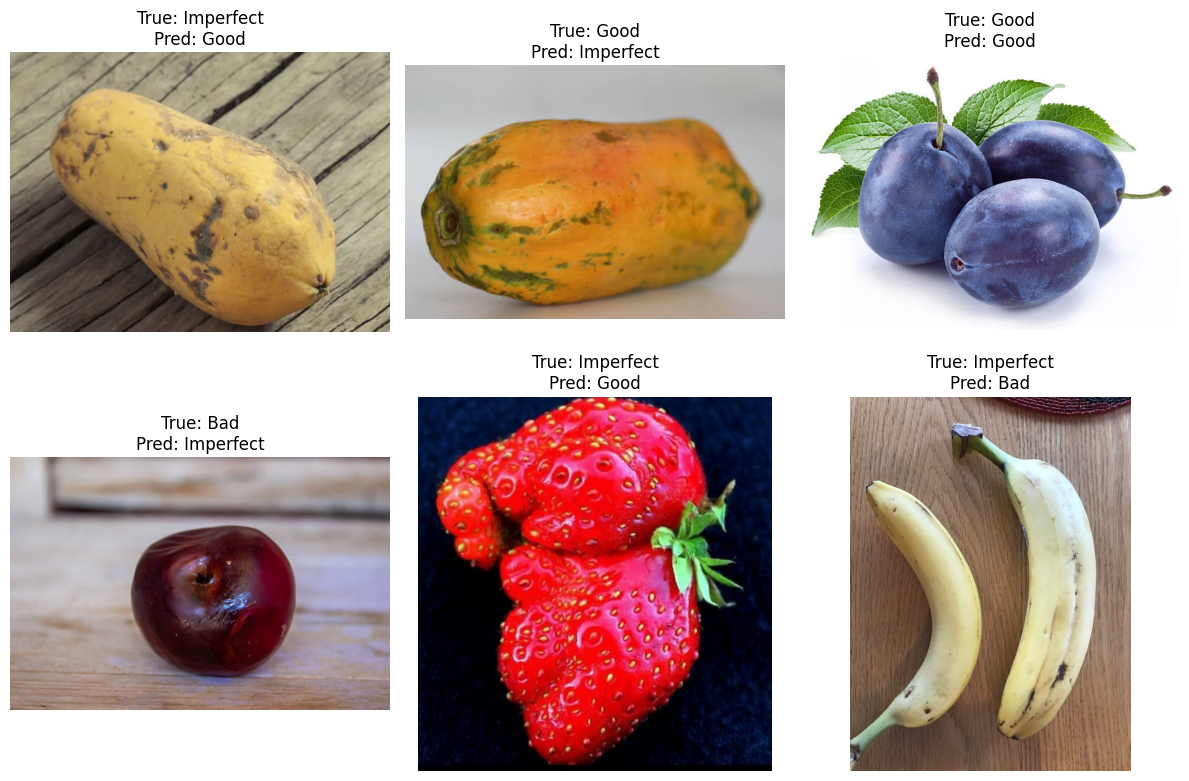

In [64]:



misclassified = test_results[test_results["true"] != test_results["pred"]].reset_index()


num_to_show = min(6, len(misclassified))

if num_to_show == 0:
    print("No misclassified images to show.")
else:

    sampled_idxs = misclassified.sample(n=num_to_show)["index"].tolist()

    plt.figure(figsize=(12, 8))

    for i, idx in enumerate(sampled_idxs):
        img_name = test_df.iloc[idx]["filename"]
        img = Image.open(os.path.join(DATASET_PATH, img_name))
        true_label = class_names[test_df.iloc[idx]["label"]]
        pred_label = class_names[y_pred_adv[idx]]

        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


In Summary: The advanced model was evaluated on the test set using accuracy, precision, recall, and F1-score for each class. The confusion matrix confirmed improved recognition of bad fruits compared to the baseline.

A detailed analysis of misclassified images revealed that most errors occur under challenging conditions such as unusual lighting, occlusions, or subtle defects. False positives and false negatives were quantified per class, providing insight into typical model limitations.

Overall, the advanced transfer learning model demonstrates significantly better performance in detecting severely defective fruits while maintaining strong accuracy on the majority classes.

# Saving the Model

In [65]:
save_path = "/content/drive/MyDrive/FruitModel.pth"


torch.save(model, save_path)


# Grad-CAM

### Grad-CAM: Visualizing Model Decisions

Grad-CAM lets you see what the model focuses on by highlighting the pixels that influenced its prediction.

By using model.features[-1], you capture the richest visual features, showing where the model detects things like bruises or mold.

A correct prediction lights up the relevant part of the fruit. If the heatmap highlights the background instead, the model is relying on irrelevant cues.

The overlay_mask blends the heatmap with the original image: red areas show high importance, blue areas are ignored.

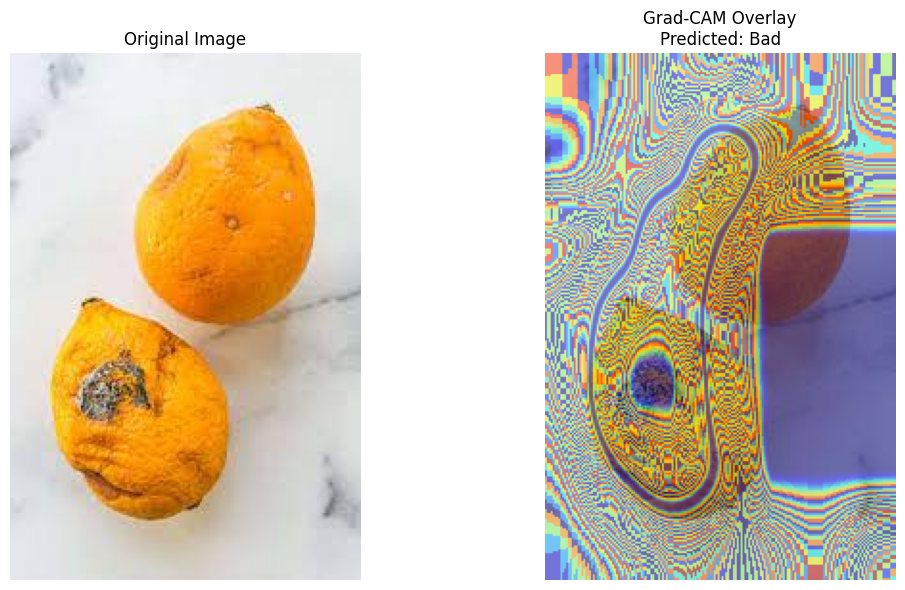

Randomly selected image: Lemon_bad (1).jpg


In [80]:
model = torch.load(save_path, weights_only=False)

class_names = ["Good", "Imperfect", "Bad"]


DATASET_PATH = "/content/drive/MyDrive/All Fruits/All Fruits/"


all_images = [f for f in os.listdir(DATASET_PATH) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]


img_name = random.choice(all_images)
img_path = os.path.join(DATASET_PATH, img_name)
img = Image.open(img_path).convert("RGB")


transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
input_tensor = transform(img).unsqueeze(0).to(device)


last_conv_layer = model.features[-1]
cam_extractor = GradCAM(model, target_layer=last_conv_layer)

# Forward pass
model.eval()
out = model(input_tensor)

# Predicted class
pred_class = out.argmax(dim=1).item()

# CAM
activation_map = cam_extractor(pred_class, out)

# Convert CAM tensor -> PIL.Image
cam_pil = ToPILImage()(activation_map[0].squeeze(0).cpu())

# Overlay sul originale
result = overlay_mask(img, cam_pil, alpha=0.5)

# Plot affiancato: originale + Grad-CAM
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(result)
plt.title(f"Grad-CAM Overlay\nPredicted: {class_names[pred_class]}")
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Randomly selected image: {img_name}")


The resulting heatmaps highlight that the network focuses specifically on the defective areas of the lemon.

This indicates that the network is correctly attending to the most relevant visual features for determining quality, supporting the prediction of “Bad” and demonstrating that the model learned meaningful cues from the fruit’s surface rather than being influenced by the surrounding context in this scenario.